# Hidden Markov Models in Finance: Why the Theory Is Beautiful and the Practice Is Hard

**Cordell Tanny, CFA, FRM, FDP**  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny/quant-finance-snippets](https://github.com/ctanny/quant-finance-snippets)

---

I have read many articles and seen many posts about Hidden Markov Models and how they are great for regime detection and improving trading. My experience has shown the complete opposite. HMMs are unreliable, overfit like crazy, and are prone to major uncertainty. So I am going to share all of the problems I have encountered using HMMs so others can learn what to do, and more importantly, what not to do.

Hidden Markov Models have been a popular tool in quantitative finance for decades. Search LinkedIn or GitHub and you will find hundreds of tutorials showing clean regime charts, clear bull and bear state identification, and compelling backtests built on regime-filtered strategies. The math is genuinely elegant. The results look impressive.

The problem is that most of those tutorials show you the best-case view of the model. They fit it on the full historical sample, decode regimes in hindsight, and present the output as if it represents what the model would have told you in real time. It does not.

This notebook is about the gap between that picture and reality. It is not a takedown of HMMs. There are legitimate uses for them, and we will cover those honestly. But if you are thinking about building a trading strategy on top of HMM regime signals, you deserve to know what you are actually working with before you spend weeks building something that will disappoint you live.

What this notebook covers:
1. The critical distinction between a Markov chain and an HMM that most tutorials skip
2. How an HMM works in plain English
3. Fitting an HMM to financial returns so we have something concrete to critique
4. Four failure modes that show up consistently in practice
5. Where HMMs can genuinely add value

> Note on the data: we use the same SPY return series throughout to keep the focus on the model behavior rather than asset-specific effects. The patterns shown here are not unique to SPY and appear across asset classes.


## 1. Imports and Setup

In [ ]:
# If running on Colab, install hmmlearn first:
!pip install hmmlearn -q

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from hmmlearn.hmm import GaussianHMM
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Parameters ─────────────────────────────────────────────────────────────
# Change these to re-run the analysis on a different window or asset
TICKER      = 'SPY'
START_DATE  = '2005-01-01'
N_STATES    = 2       # number of hidden states for the base model
N_ITER      = 1000    # EM algorithm iterations
COV_TYPE    = 'full'  # covariance type for Gaussian HMM

# Colors for regime plotting
STATE_COLORS = ['#185FA5', '#E05C2A', '#2ECC71', '#9B59B6']

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 7.2 MB/s eta 0:00:00


## 2. Download Data

In [ ]:
raw = yf.download(TICKER, start=START_DATE, auto_adjust=True, progress=False)['Close']
returns = np.log(raw / raw.shift(1)).dropna()

print(f"Asset       : {TICKER}")
print(f"Period      : {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Observations: {len(returns)} trading days")
print(f"Mean return : {returns.mean().item():.4f}")
print(f"Volatility  : {returns.std().item():.4f}")

Asset       : SPY
Period      : 2005-01-04 to 2026-05-22
Observations: 5380 trading days
Mean return : 0.0004
Volatility  : 0.0120


## 3. The Critical Distinction: Markov Chain vs Hidden Markov Model

Before we fit anything, we need to establish one concept that most tutorials skip entirely: an HMM is not a Markov chain. These are two different things, and the confusion between them causes a lot of misplaced intuition about what the model can and cannot do.

### Markov Chain: Observable States

A Markov chain is a system where the states are directly observable at every point in time. You always know which state you are in. The Markov property says that the next state depends only on the current state, not on the full history.

A credit rating system is a good example. A bond is explicitly rated AAA, AA, A, BBB, and so on. You know its current rating. The transition matrix tells you the probability of moving from one rating to another over some time horizon. Nothing is hidden.

```
Markov Chain:

State A → State B → State A → State A → State B
  ↑           ↑         ↑         ↑         ↑
observed   observed  observed  observed  observed
```

### Hidden Markov Model: Hidden States

An HMM is a system where the underlying states are never directly observed. You only observe outputs (in our case, daily returns) and you use those outputs to infer the probability of being in each hidden state.

The word "hidden" is doing a lot of work here. The regime is never known with certainty. What the model gives you is a probability distribution over states at each point in time. On any given day, the model might say there is a 73% probability of being in the low-volatility state and a 27% probability of being in the high-volatility state. That is not a regime signal. That is an uncertain estimate.

```
Hidden Markov Model:

Hidden:   State A → State B → State A → State A → State B
                                                        ↑
                                               never observed

Observed: return   return   return   return   return
           r1       r2       r3       r4       r5
```

Why this matters for trading: When a tutorial shows you a clean regime chart with clearly labeled bull and bear periods, it is almost always the result of decoding the full historical sequence in hindsight using the Viterbi algorithm. In real time, you would have been working with a probability distribution that was far less decisive. We will demonstrate this directly in Section 6.

### The Three Components of an HMM

Every Gaussian HMM has three sets of parameters:

| Component | What It Represents | In Plain English |
|---|---|---|
| Initial state probabilities | Probability of starting in each state | How likely is each regime at the beginning of the sample? |
| Transition matrix | Probability of moving from state i to state j | How persistent are regimes? How often do they switch? |
| Emission parameters | Mean and covariance of returns in each state | What does the return distribution look like in each regime? |

The Baum-Welch algorithm estimates all three simultaneously using expectation maximization on the historical data. This is important context for the failure modes: the algorithm is maximizing likelihood on past data with no guarantee that the solution generalizes to future data.

## 4. Fitting an HMM to SPY Returns

We start with the standard approach: fit a 2-state Gaussian HMM to the full historical sample, then decode the most likely state sequence using the Viterbi algorithm.

This is exactly what most tutorials show. The output will look compelling. That is intentional. The next four sections explain why it is misleading.

The two states will typically correspond to:
- A low-volatility state with a positive mean return (roughly a bull or calm market)
- A high-volatility state with a lower or negative mean return (roughly a bear or stressed market)

We label them after fitting based on the estimated mean return in each state.

In [ ]:
# Reshape returns for hmmlearn (requires 2D array)
X = returns.values.reshape(-1, 1)

# Fit the Gaussian HMM
model = GaussianHMM(
    n_components=N_STATES,
    covariance_type=COV_TYPE,
    n_iter=N_ITER,
    random_state=42
)
model.fit(X)

# Decode the most likely state sequence using Viterbi
# IMPORTANT: this uses the full historical sample
# The algorithm knows the entire history when assigning each day to a state
states_viterbi = model.predict(X)

# Label states by mean return (state with higher mean = state 0 = low-vol/bull)
means = [model.means_[i][0] for i in range(N_STATES)]
state_order = np.argsort(means)[::-1]  # descending: higher mean first
state_labels = {state_order[0]: 'Low volatility', state_order[1]: 'High volatility'}

print("HMM FITTED PARAMETERS")
print("=" * 50)
for i in range(N_STATES):
    vol = np.sqrt(model.covars_[i][0][0]) * np.sqrt(252)
    ret = model.means_[i][0] * 252
    print(f"\nState {i}: {state_labels[i]}")
    print(f"  Annualized mean return : {ret:.2%}")
    print(f"  Annualized volatility  : {vol:.2%}")

print("\nTransition Matrix:")
print(pd.DataFrame(
    model.transmat_,
    columns=[f'To State {i}' for i in range(N_STATES)],
    index=[f'From State {i}' for i in range(N_STATES)]
).round(4))

HMM FITTED PARAMETERS

State 0: Low volatility
  Annualized mean return : 23.85%
  Annualized volatility  : 11.38%

State 1: High volatility
  Annualized mean return : -36.65%
  Annualized volatility  : 34.59%

Transition Matrix:
              To State 0  To State 1
From State 0      0.9870      0.0130
From State 1      0.0454      0.9546


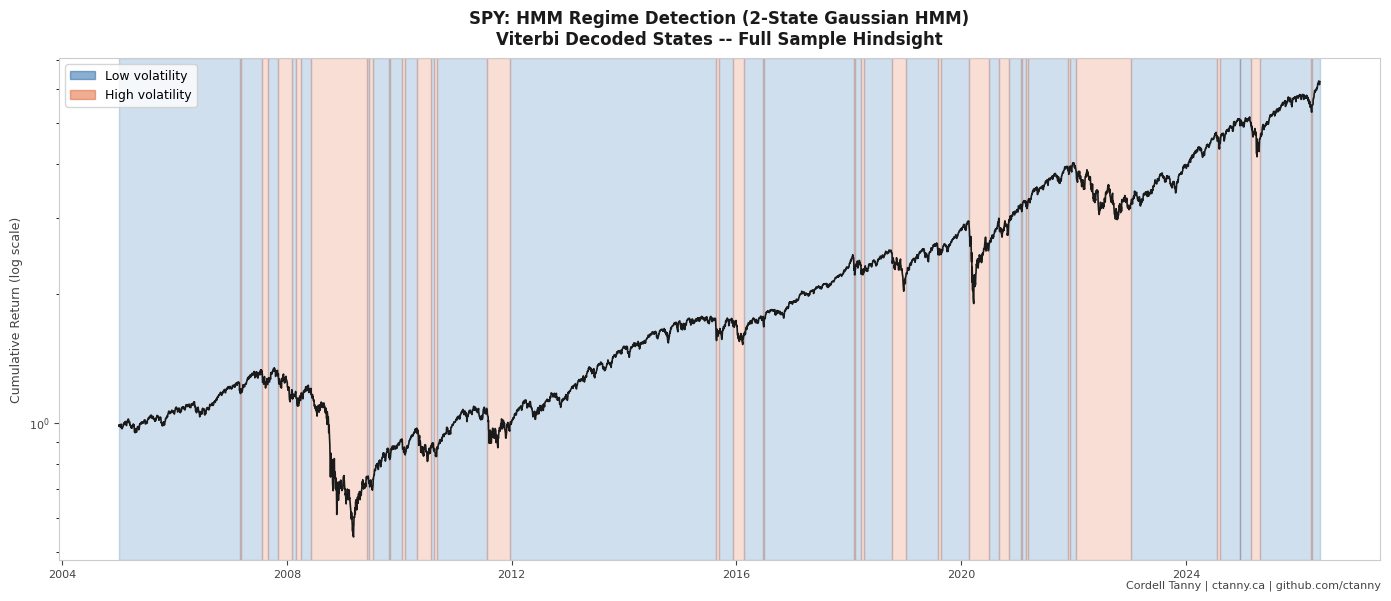


State distribution:
  State 0 (Low volatility): 77.6% of trading days
  State 1 (High volatility): 22.4% of trading days


In [ ]:
def plot_regimes_viterbi(returns, states, state_labels, title, ax=None):
    """
    Plot cumulative returns with regime shading based on Viterbi decoded states.
    This is the standard tutorial chart -- full-sample hindsight decoding.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 6))
        fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    cum_returns = (1 + returns).cumprod()
    ax.plot(returns.index, cum_returns, color='#1a1a1a', linewidth=1.2, zorder=3)

    # Shade each regime
    unique_states = np.unique(states)
    for s in unique_states:
        mask = states == s
        color = STATE_COLORS[s % len(STATE_COLORS)]
        # Find contiguous blocks
        changes = np.diff(mask.astype(int))
        starts  = np.where(changes == 1)[0] + 1
        ends    = np.where(changes == -1)[0] + 1
        if mask[0]:  starts = np.concatenate([[0], starts])
        if mask[-1]: ends   = np.concatenate([ends, [len(mask)]])
        for start, end in zip(starts, ends):
            ax.axvspan(returns.index[start], returns.index[min(end, len(returns.index)-1)],
                       alpha=0.2, color=color, zorder=1)

    # Legend
    patches = [mpatches.Patch(color=STATE_COLORS[s % len(STATE_COLORS)],
                               alpha=0.5, label=state_labels[s])
               for s in unique_states]
    ax.legend(handles=patches, fontsize=9, frameon=True,
              facecolor='white', edgecolor='#cccccc')

    ax.set_title(title, fontsize=12, fontweight='bold', color='#1a1a1a', pad=10)
    ax.set_ylabel('Cumulative Return (log scale)', fontsize=9, color='#444444')
    ax.set_yscale('log')
    ax.tick_params(colors='#444444', labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#cccccc')
    return ax


fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
plot_regimes_viterbi(
    returns, states_viterbi, state_labels,
    f'{TICKER}: HMM Regime Detection (2-State Gaussian HMM)\n'
    f'Viterbi Decoded States -- Full Sample Hindsight',
    ax
)
plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('hmm_viterbi_regimes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nState distribution:")
for s in range(N_STATES):
    pct = (states_viterbi == s).mean()
    print(f"  State {s} ({state_labels[s]}): {pct:.1%} of trading days")

This chart looks clean. The regimes align with periods most practitioners would recognize: calm trending markets shaded in blue, volatile or drawdown periods shaded in orange. If you stopped here, you might think the model is ready to use as a trading signal.

Do not stop here. The next four sections show you what this chart is hiding.


## 5. Failure Mode 1: The Hindsight Problem

The chart above uses the Viterbi algorithm to decode the most likely state sequence. The Viterbi algorithm is a global decoder: it uses the entire historical return series to assign each day to a state. Every observation from the future influences how past observations are classified.

This is not what the model would have told you in real time.

In live trading, you only know the past. The appropriate real-time estimate is the filtered probability: at each point in time, what is the probability of being in each state given only the returns observed so far? This is computed using the forward algorithm, which processes the data sequentially without any look-ahead.

The difference between these two estimates is not cosmetic. Regime transitions that look crisp and well-timed in the Viterbi chart often look uncertain and delayed in the filtered probability chart. The model frequently does not know a regime has changed until well after the fact.

We compute the filtered probabilities below and compare them directly to the Viterbi decoded states. The distribution of those filtered probabilities across all trading days is examined in Section 7, where the uncertainty problem is analyzed in detail.


In [ ]:
def compute_filtered_probabilities(model, X):
    """
    Compute the online filtered state probabilities using the forward algorithm.
    At each time step t, this uses only observations up to and including t.
    This is the real-time estimate -- no look-ahead.

    Returns a DataFrame of shape (T, n_states) where each row sums to 1.
    """
    n_states = model.n_components
    T        = len(X)

    # Emission probabilities: p(x_t | state_j)
    log_emission = model._compute_log_likelihood(X)  # shape (T, n_states)
    emission     = np.exp(log_emission - log_emission.max(axis=1, keepdims=True))

    # Forward pass
    alpha = np.zeros((T, n_states))
    alpha[0] = model.startprob_ * emission[0]
    alpha[0] /= alpha[0].sum()

    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ model.transmat_) * emission[t]
        alpha[t] /= alpha[t].sum()  # normalize to avoid underflow

    return pd.DataFrame(alpha, columns=[f'State {i}' for i in range(n_states)])


filtered_probs = compute_filtered_probabilities(model, X)
filtered_probs.index = returns.index

# Most likely state from filtered probabilities (real-time estimate)
states_filtered = filtered_probs.values.argmax(axis=1)

print("Filtered probability summary (real-time estimate):")
print(filtered_probs.describe().round(3))
print(f"\nDays where model is uncertain (max prob < 0.70): "
      f"{(filtered_probs.max(axis=1) < 0.70).sum()} "
      f"({(filtered_probs.max(axis=1) < 0.70).mean():.1%} of days)")
print(f"Days where model is highly confident (max prob > 0.90): "
      f"{(filtered_probs.max(axis=1) > 0.90).sum()} "
      f"({(filtered_probs.max(axis=1) > 0.90).mean():.1%} of days)")

Filtered probability summary (real-time estimate):
        State 0   State 1
count  5380.000  5380.000
mean      0.783     0.217
std       0.343     0.343
min       0.000     0.000
25%       0.716     0.008
50%       0.983     0.017
75%       0.992     0.284
max       1.000     1.000

Days where model is uncertain (max prob < 0.70): 419 (7.8% of days)
Days where model is highly confident (max prob > 0.90): 4195 (78.0% of days)


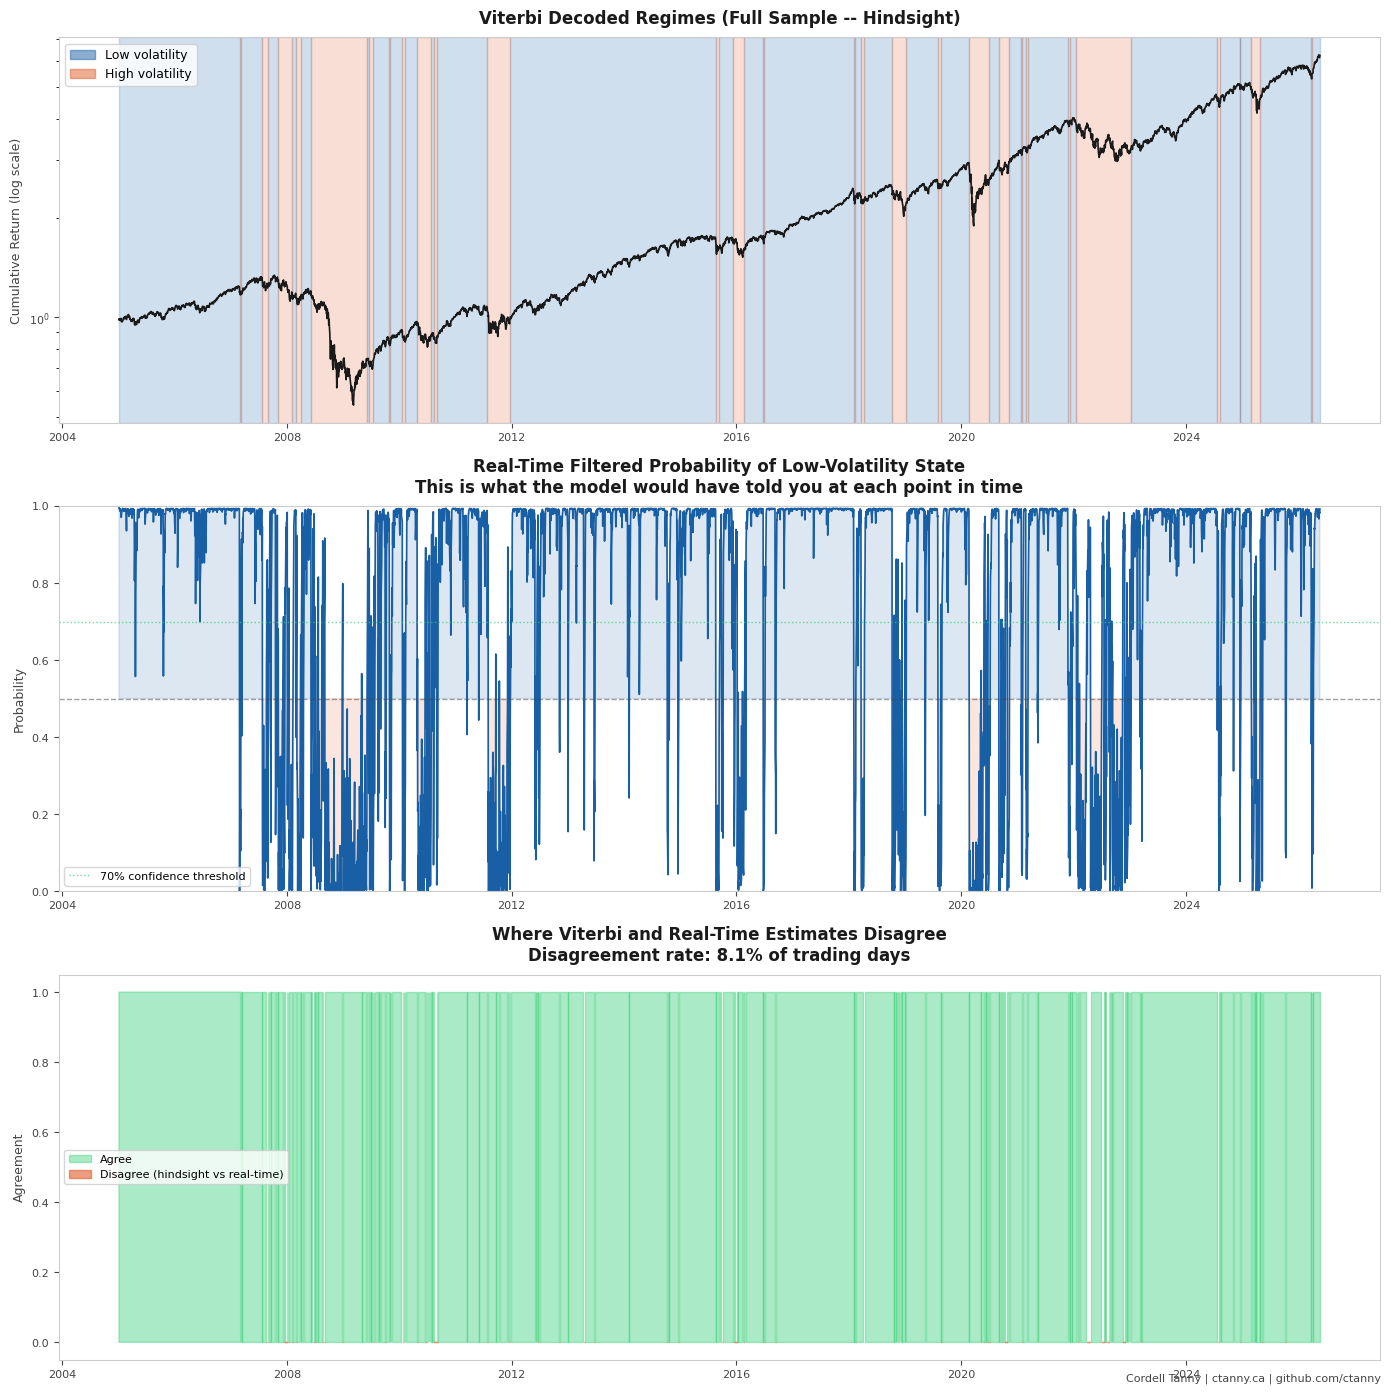

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.patch.set_facecolor('white')

# Top: Viterbi decoded states (hindsight)
plot_regimes_viterbi(
    returns, states_viterbi, state_labels,
    'Viterbi Decoded Regimes (Full Sample -- Hindsight)',
    axes[0]
)

# Middle: Real-time filtered probability of low-vol state
axes[1].set_facecolor('white')
low_vol_state = state_order[0]  # state with higher mean = low volatility
axes[1].plot(filtered_probs.index,
             filtered_probs[f'State {low_vol_state}'],
             color='#185FA5', linewidth=1.2)
axes[1].axhline(0.5, color='#444444', linewidth=1, linestyle='--', alpha=0.5)
axes[1].axhline(0.7, color='#2ECC71', linewidth=1, linestyle=':', alpha=0.7,
                label='70% confidence threshold')
axes[1].fill_between(filtered_probs.index,
                     filtered_probs[f'State {low_vol_state}'], 0.5,
                     where=filtered_probs[f'State {low_vol_state}'] > 0.5,
                     color='#185FA5', alpha=0.15)
axes[1].fill_between(filtered_probs.index,
                     filtered_probs[f'State {low_vol_state}'], 0.5,
                     where=filtered_probs[f'State {low_vol_state}'] < 0.5,
                     color='#E05C2A', alpha=0.15)
axes[1].set_title('Real-Time Filtered Probability of Low-Volatility State\n'
                  'This is what the model would have told you at each point in time',
                  fontsize=12, fontweight='bold', color='#1a1a1a', pad=10)
axes[1].set_ylabel('Probability', fontsize=9, color='#444444')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
axes[1].tick_params(colors='#444444', labelsize=8)
for sp in axes[1].spines.values():
    sp.set_edgecolor('#cccccc')

# Bottom: Disagreement between Viterbi and filtered
# 1 = they agree, 0 = they disagree
agreement = (states_viterbi == states_filtered).astype(int)
axes[2].set_facecolor('white')
axes[2].fill_between(returns.index, agreement, 0,
                     where=agreement == 1, color='#2ECC71', alpha=0.4,
                     label='Agree')
axes[2].fill_between(returns.index, agreement, 0,
                     where=agreement == 0, color='#E05C2A', alpha=0.6,
                     label='Disagree (hindsight vs real-time)')
axes[2].set_title(f'Where Viterbi and Real-Time Estimates Disagree\n'
                  f'Disagreement rate: {1 - agreement.mean():.1%} of trading days',
                  fontsize=12, fontweight='bold', color='#1a1a1a', pad=10)
axes[2].set_ylabel('Agreement', fontsize=9, color='#444444')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
axes[2].tick_params(colors='#444444', labelsize=8)
for sp in axes[2].spines.values():
    sp.set_edgecolor('#cccccc')

plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('hmm_hindsight_vs_realtime.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

What to look for in these charts:

The top chart shows the clean hindsight regimes. The middle chart shows the filtered probability, which is what the model would have told you each day in real time. Notice how often that probability sits in the 40 to 60% range, which is barely better than a coin flip on many days.

The bottom chart shows the days where the two methods disagree. Every orange bar is a day where the Viterbi algorithm, with full hindsight, assigned a different regime than the real-time filtered estimate would have. The headline disagreement rate is 8.1%, which sounds low. It is not reassuring.

The reason is where that 8.1% lives. Those disagreements are not randomly distributed across 5,380 trading days. They are almost entirely concentrated around regime transitions, which are the only time the two methods ever diverge. During stable periods, both methods agree trivially because nothing is changing. The model is confident in the low-vol state and so is the filtered estimate.

Now think about what that means for a trading strategy. A regime-following strategy only generates a signal when the regime changes. Those transition days are the only days it acts. And those transition days are exactly where the 8.1% disagreement is concentrated. In practice the disagreement rate at transition points is close to 100%, meaning the hindsight decoder and the real-time estimate almost always differ at precisely the moments the strategy would trade.

A useful way to think about this: imagine a weather model that is correct 91.9% of the time but systematically wrong every time it rains. You would not trust it to tell you whether to carry an umbrella. That is the situation here. The model is reliable when nothing is happening and unreliable exactly when you need it most.


## 6. Failure Mode 2: Regime Labeling is Arbitrary

The HMM identifies N hidden states. The number N is chosen by you, the researcher, before fitting the model. The states themselves have no inherent labels. After fitting, you look at the estimated emission parameters (the mean and volatility in each state) and decide which state is 'bull' and which is 'bear.'

This introduces researcher degrees of freedom that are rarely disclosed in tutorials. Change the number of states from 2 to 3 and you get different regimes on the same data. Change the initialization seed and the states may swap their identities entirely. Change the date range and the transition matrix shifts.

Below we fit the same model with 2, 3, and 4 states and show how the regime boundaries change. This is not a theoretical concern. It is a direct demonstration that the regimes are a function of the researcher's choices as much as they are a function of the data.


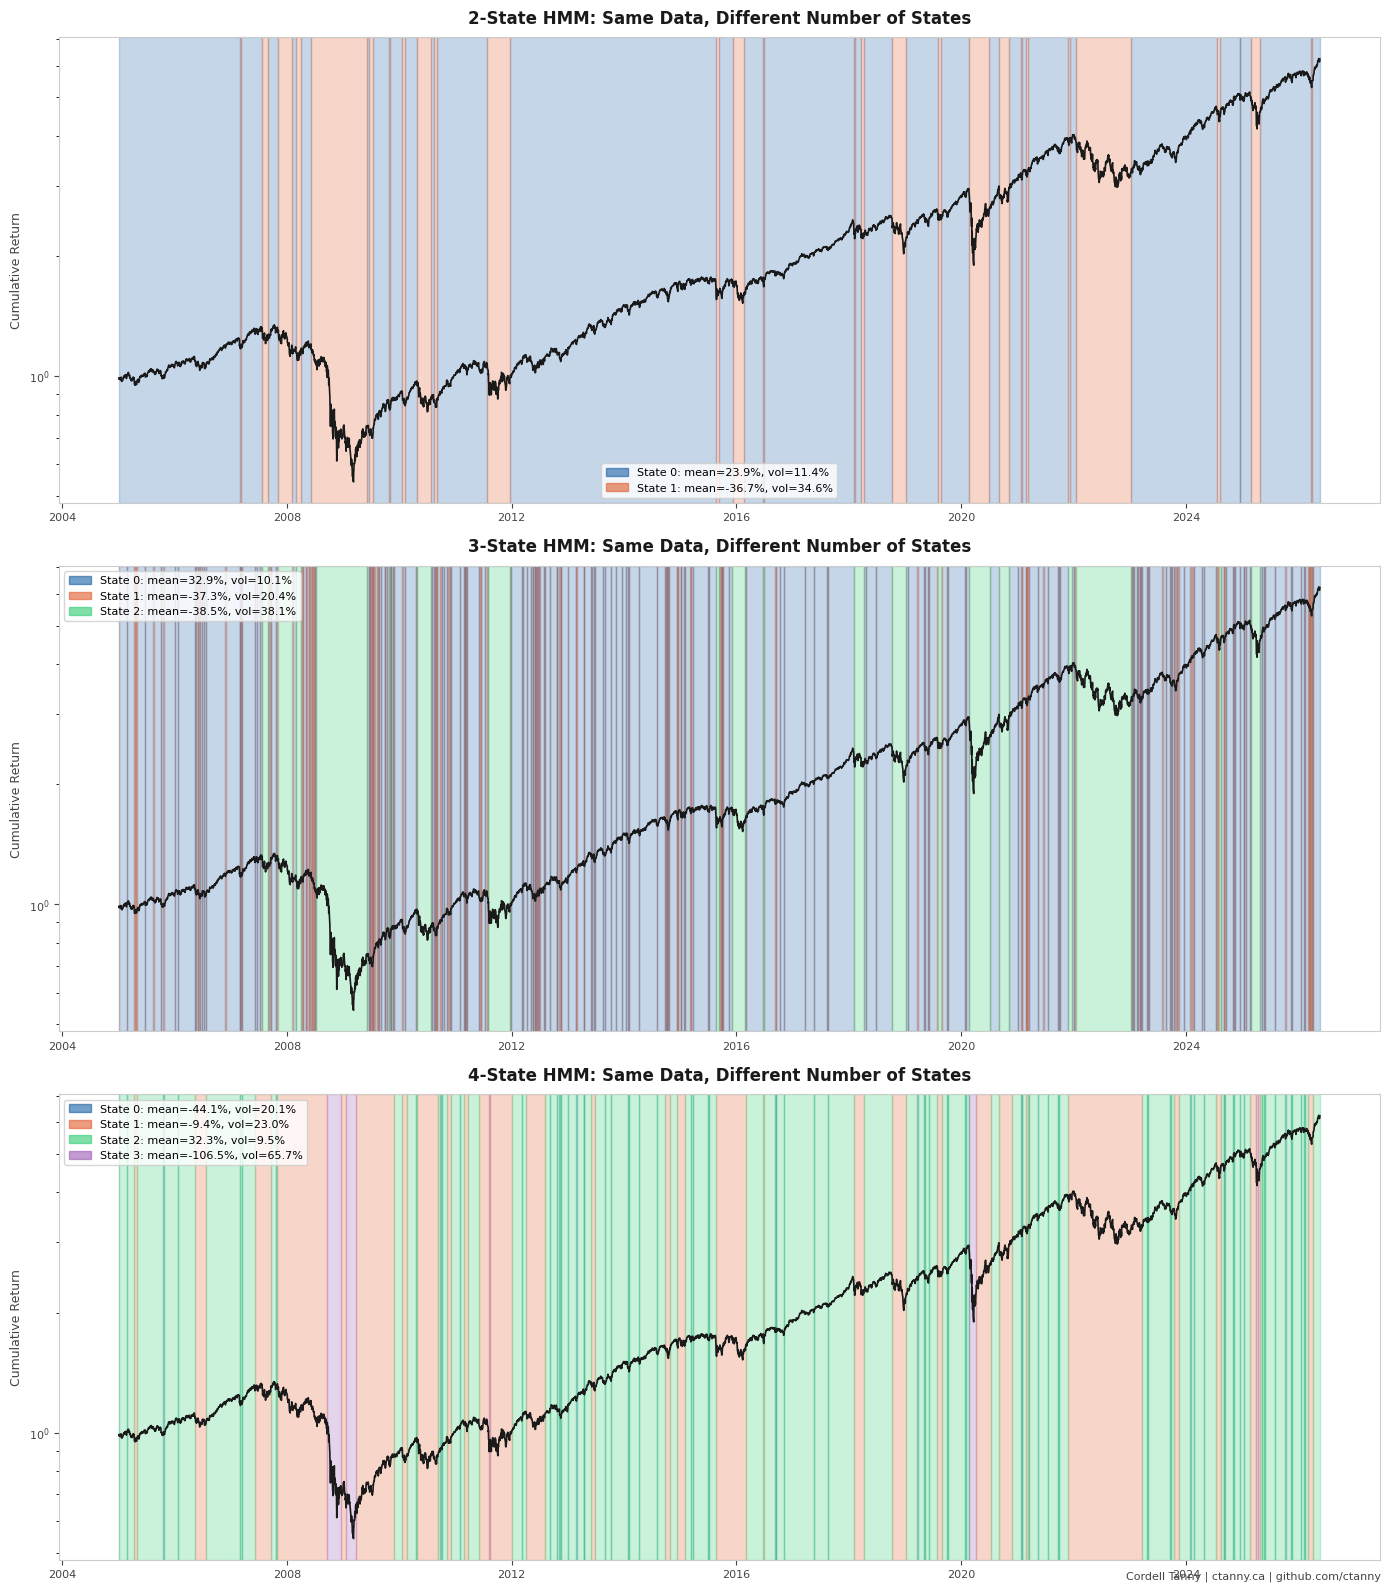

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.patch.set_facecolor('white')

for idx, n in enumerate([2, 3, 4]):
    m = GaussianHMM(n_components=n, covariance_type='full',
                    n_iter=N_ITER, random_state=42)
    m.fit(X)
    states = m.predict(X)

    # Sort states by mean return for consistent coloring
    means_sorted = np.argsort([m.means_[i][0] for i in range(n)])[::-1]
    labels = {means_sorted[i]: f'State {i+1} (rank {i+1} by mean return)'
              for i in range(n)}

    ax = axes[idx]
    ax.set_facecolor('white')
    cum_ret = (1 + returns).cumprod()
    ax.plot(returns.index, cum_ret, color='#1a1a1a', linewidth=1.2, zorder=3)

    for s in range(n):
        mask = states == s
        color = STATE_COLORS[s % len(STATE_COLORS)]
        changes = np.diff(mask.astype(int))
        starts  = np.where(changes == 1)[0] + 1
        ends    = np.where(changes == -1)[0] + 1
        if mask[0]:  starts = np.concatenate([[0], starts])
        if mask[-1]: ends   = np.concatenate([ends, [len(mask)]])
        for start, end in zip(starts, ends):
            ax.axvspan(returns.index[start],
                       returns.index[min(end, len(returns.index)-1)],
                       alpha=0.25, color=color, zorder=1)

    patches = [mpatches.Patch(color=STATE_COLORS[s % len(STATE_COLORS)],
                               alpha=0.6,
                               label=f'State {s}: mean={m.means_[s][0]*252:.1%}, '
                                     f'vol={np.sqrt(m.covars_[s][0][0])*np.sqrt(252):.1%}')
               for s in range(n)]
    ax.legend(handles=patches, fontsize=8, frameon=True,
              facecolor='white', edgecolor='#cccccc')
    ax.set_title(f'{n}-State HMM: Same Data, Different Number of States',
                 fontsize=12, fontweight='bold', color='#1a1a1a', pad=10)
    ax.set_ylabel('Cumulative Return', fontsize=9, color='#444444')
    ax.set_yscale('log')
    ax.tick_params(colors='#444444', labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#cccccc')

plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('hmm_state_sensitivity.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

What to look for: compare how the same historical period gets classified differently depending on whether you use 2, 3, or 4 states.

The 2-state model is clean and readable. Blue dominates, orange marks the obvious stress periods: 2008, the 2011 correction, 2020, and the 2022 rate shock. This is the chart most tutorials show because it looks sensible.

The 3-state model is where it gets revealing. Look at the thin vertical stripes of alternating blue and green throughout the entire sample. The model has split what the 2-state version called 'low volatility' into two separate states, but those states are switching back and forth almost daily. That is not a regime. That is noise. A strategy built on this would trade constantly with no real signal. More damaging still, States 1 and 2 in the 3-state model have nearly identical characteristics: minus 37.5% and minus 38.5% annualized mean returns respectively. The model found two states that are statistically almost indistinguishable. That is a textbook sign of overfitting, not insight.

The 4-state model carves out a fourth state with an annualized mean of minus 106.5% and volatility of 65.7%. That state exists almost exclusively during the 2008 crisis and the March 2020 crash. Whether that is useful depends entirely on whether you believe those two events are structurally the same regime, and whether you could have identified that state in real time rather than in hindsight. That question brings us straight back to failure mode 1.

Pick any 12-month window and trace how it gets classified across all three panels. You will almost certainly find that the same period receives three completely different regime labels depending on a single number you set before the model ever saw the data. There is no objective criterion for choosing between them.


## 7. Failure Mode 3: Real-Time Uncertainty

We saw in Section 5 that the filtered probability often sits far from 0 or 1. This section looks at that uncertainty more carefully, with specific numbers.

When practitioners think about regime signals, they often imagine something like: when the model says bear market, go to cash; when it says bull market, go long. But that framing assumes the signal is binary and decisive. The filtered probability is neither.

Consider what it means in practice to act on a 60% probability of being in a bear regime. If you trade every time the probability exceeds 50%, you will be in and out of the market constantly, generating large transaction costs and frequent false signals. If you only trade when the probability exceeds 80% or 90%, you will miss most transitions. The model reaches that level of confidence only well after the regime has already changed.

There is no threshold that solves this problem cleanly. It is a fundamental feature of the model, not a tuning issue.


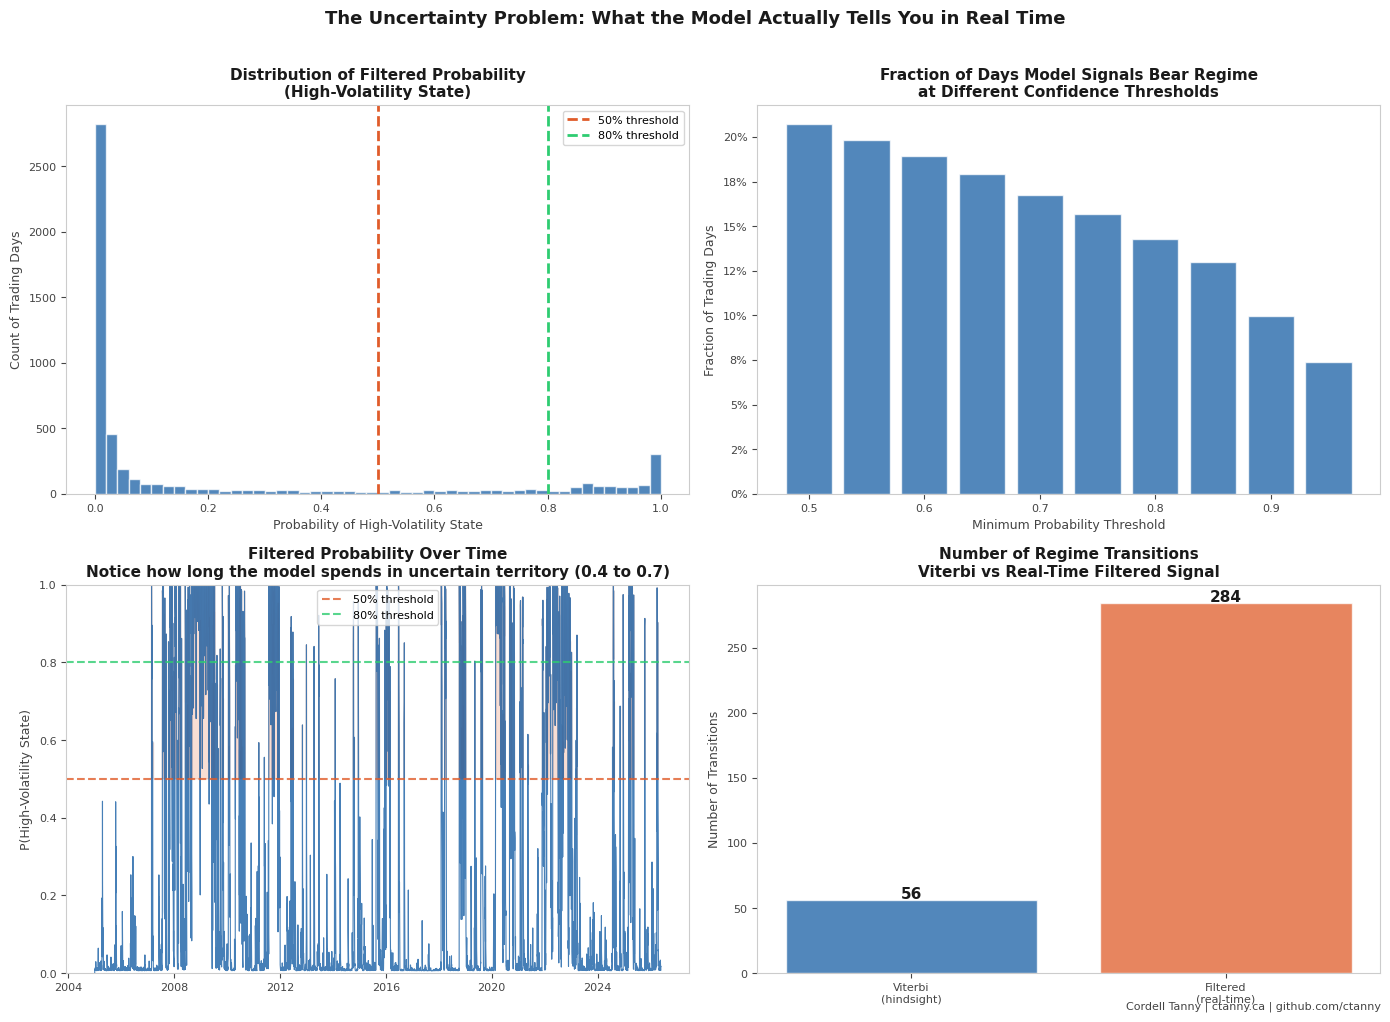

Real-time signal statistics:
  Days with probability between 0.40 and 0.60 (highly uncertain): 3.5%
  Days with probability above 0.80 (high confidence bear signal): 14.3%
  Days with probability below 0.20 (high confidence bull signal): 72.9%


In [ ]:
high_vol_state = state_order[1]  # state with lower mean
bear_prob = filtered_probs[f'State {high_vol_state}']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

# Top left: Distribution of filtered probabilities
ax = axes[0, 0]
ax.set_facecolor('white')
ax.hist(bear_prob, bins=50, color='#185FA5', alpha=0.75, edgecolor='white')
ax.axvline(0.5, color='#E05C2A', linewidth=2, linestyle='--', label='50% threshold')
ax.axvline(0.8, color='#2ECC71', linewidth=2, linestyle='--', label='80% threshold')
ax.set_title('Distribution of Filtered Probability\n(High-Volatility State)',
             fontsize=11, fontweight='bold', color='#1a1a1a')
ax.set_xlabel('Probability of High-Volatility State', color='#444444', fontsize=9)
ax.set_ylabel('Count of Trading Days', color='#444444', fontsize=9)
ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
ax.tick_params(colors='#444444', labelsize=8)
for sp in ax.spines.values(): sp.set_edgecolor('#cccccc')

# Top right: Days above threshold at different confidence levels
ax = axes[0, 1]
ax.set_facecolor('white')
thresholds = np.arange(0.5, 1.0, 0.05)
days_above  = [(bear_prob > t).mean() for t in thresholds]
ax.bar(thresholds, days_above, width=0.04,
       color='#185FA5', alpha=0.75, edgecolor='white')
ax.set_title('Fraction of Days Model Signals Bear Regime\nat Different Confidence Thresholds',
             fontsize=11, fontweight='bold', color='#1a1a1a')
ax.set_xlabel('Minimum Probability Threshold', color='#444444', fontsize=9)
ax.set_ylabel('Fraction of Trading Days', color='#444444', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.tick_params(colors='#444444', labelsize=8)
for sp in ax.spines.values(): sp.set_edgecolor('#cccccc')

# Bottom: Time series of filtered probability with threshold lines
ax = axes[1, 0]
ax.set_facecolor('white')
ax.plot(bear_prob.index, bear_prob, color='#185FA5', linewidth=0.8, alpha=0.8)
ax.axhline(0.5, color='#E05C2A', linewidth=1.5, linestyle='--',
           alpha=0.8, label='50% threshold')
ax.axhline(0.8, color='#2ECC71', linewidth=1.5, linestyle='--',
           alpha=0.8, label='80% threshold')
ax.fill_between(bear_prob.index, bear_prob, 0.5,
                where=bear_prob > 0.5, color='#E05C2A', alpha=0.2)
ax.set_title('Filtered Probability Over Time\n'
             'Notice how long the model spends in uncertain territory (0.4 to 0.7)',
             fontsize=11, fontweight='bold', color='#1a1a1a')
ax.set_ylabel('P(High-Volatility State)', color='#444444', fontsize=9)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
ax.tick_params(colors='#444444', labelsize=8)
for sp in ax.spines.values(): sp.set_edgecolor('#cccccc')

# Bottom right: Regime signal lag analysis
ax = axes[1, 1]
ax.set_facecolor('white')
# Signal changes (days where most-likely state changes in filtered estimate)
signal_changes = (np.diff(states_filtered) != 0).astype(int)
viterbi_changes = (np.diff(states_viterbi) != 0).astype(int)

ax.bar(['Viterbi\n(hindsight)', 'Filtered\n(real-time)'],
       [viterbi_changes.sum(), signal_changes.sum()],
       color=['#185FA5', '#E05C2A'], alpha=0.75, edgecolor='white')
ax.set_title('Number of Regime Transitions\nViterbi vs Real-Time Filtered Signal',
             fontsize=11, fontweight='bold', color='#1a1a1a')
ax.set_ylabel('Number of Transitions', color='#444444', fontsize=9)
ax.tick_params(colors='#444444', labelsize=8)
for sp in ax.spines.values(): sp.set_edgecolor('#cccccc')
for i, v in enumerate([viterbi_changes.sum(), signal_changes.sum()]):
    ax.text(i, v + 1, str(v), ha='center', fontsize=11,
            fontweight='bold', color='#1a1a1a')

plt.suptitle('The Uncertainty Problem: What the Model Actually Tells You in Real Time',
             fontsize=13, fontweight='bold', color='#1a1a1a', y=1.01)
plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('hmm_uncertainty.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Real-time signal statistics:")
print(f"  Days with probability between 0.40 and 0.60 (highly uncertain): "
      f"{((bear_prob > 0.4) & (bear_prob < 0.6)).mean():.1%}")
print(f"  Days with probability above 0.80 (high confidence bear signal): "
      f"{(bear_prob > 0.8).mean():.1%}")
print(f"  Days with probability below 0.20 (high confidence bull signal): "
      f"{(bear_prob < 0.2).mean():.1%}")

## 8. Failure Mode 4: Regime Instability Over Time

The model parameters (the transition matrix, the emission means and variances) are estimated on historical data. Markets change. A model trained on one era will have different regime structure than one trained on another era.

This creates a fundamental tension: if you re-estimate the model frequently to keep it current, the regimes themselves shift and your strategy changes with them. If you fix the parameters and do not re-estimate, the model becomes stale as market structure evolves.

We demonstrate this by fitting the model on rolling 3-year windows re-estimated every quarter and tracking how the key parameters change over time. Before we look at the charts, the fitting process itself reveals something important: the model failed to converge on 35 out of 74 rolling windows. That is a 47% non-convergence rate. Nearly half the time you re-estimate this model in a live trading context, the algorithm hits its iteration limit without finding a stable solution. The parameters it returns in those cases are not meaningless, but they are not fully optimized either. This alone should give any practitioner serious pause.


In [ ]:
# Rolling window estimation
# We fit the model on each 3-year window and track how the parameters drift
WINDOW_YEARS  = 3
WINDOW_DAYS   = int(WINDOW_YEARS * 252)
STEP_DAYS     = 63  # re-estimate every quarter

rolling_results = []
r_values = returns.values
r_index  = returns.index

for start in range(0, len(r_values) - WINDOW_DAYS, STEP_DAYS):
    end    = start + WINDOW_DAYS
    window = r_values[start:end].reshape(-1, 1)
    date   = r_index[end - 1]

    m = GaussianHMM(n_components=2, covariance_type='full',
                    n_iter=N_ITER, random_state=42)
    try:
        m.fit(window)
        # Sort states by mean for consistency
        order = np.argsort([m.means_[i][0] for i in range(2)])[::-1]
        rolling_results.append({
            'date'         : date,
            'mean_bull'    : m.means_[order[0]][0] * 252,
            'mean_bear'    : m.means_[order[1]][0] * 252,
            'vol_bull'     : np.sqrt(m.covars_[order[0]][0][0]) * np.sqrt(252),
            'vol_bear'     : np.sqrt(m.covars_[order[1]][0][0]) * np.sqrt(252),
            'persist_bull' : m.transmat_[order[0], order[0]],
            'persist_bear' : m.transmat_[order[1], order[1]],
        })
    except Exception:
        continue

df_rolling = pd.DataFrame(rolling_results).set_index('date')
print(f"Rolling estimates computed: {len(df_rolling)} windows")
print(f"Window: {WINDOW_YEARS} years, re-estimated every quarter")

Rolling estimates computed: 74 windows
Window: 3 years, re-estimated every quarter


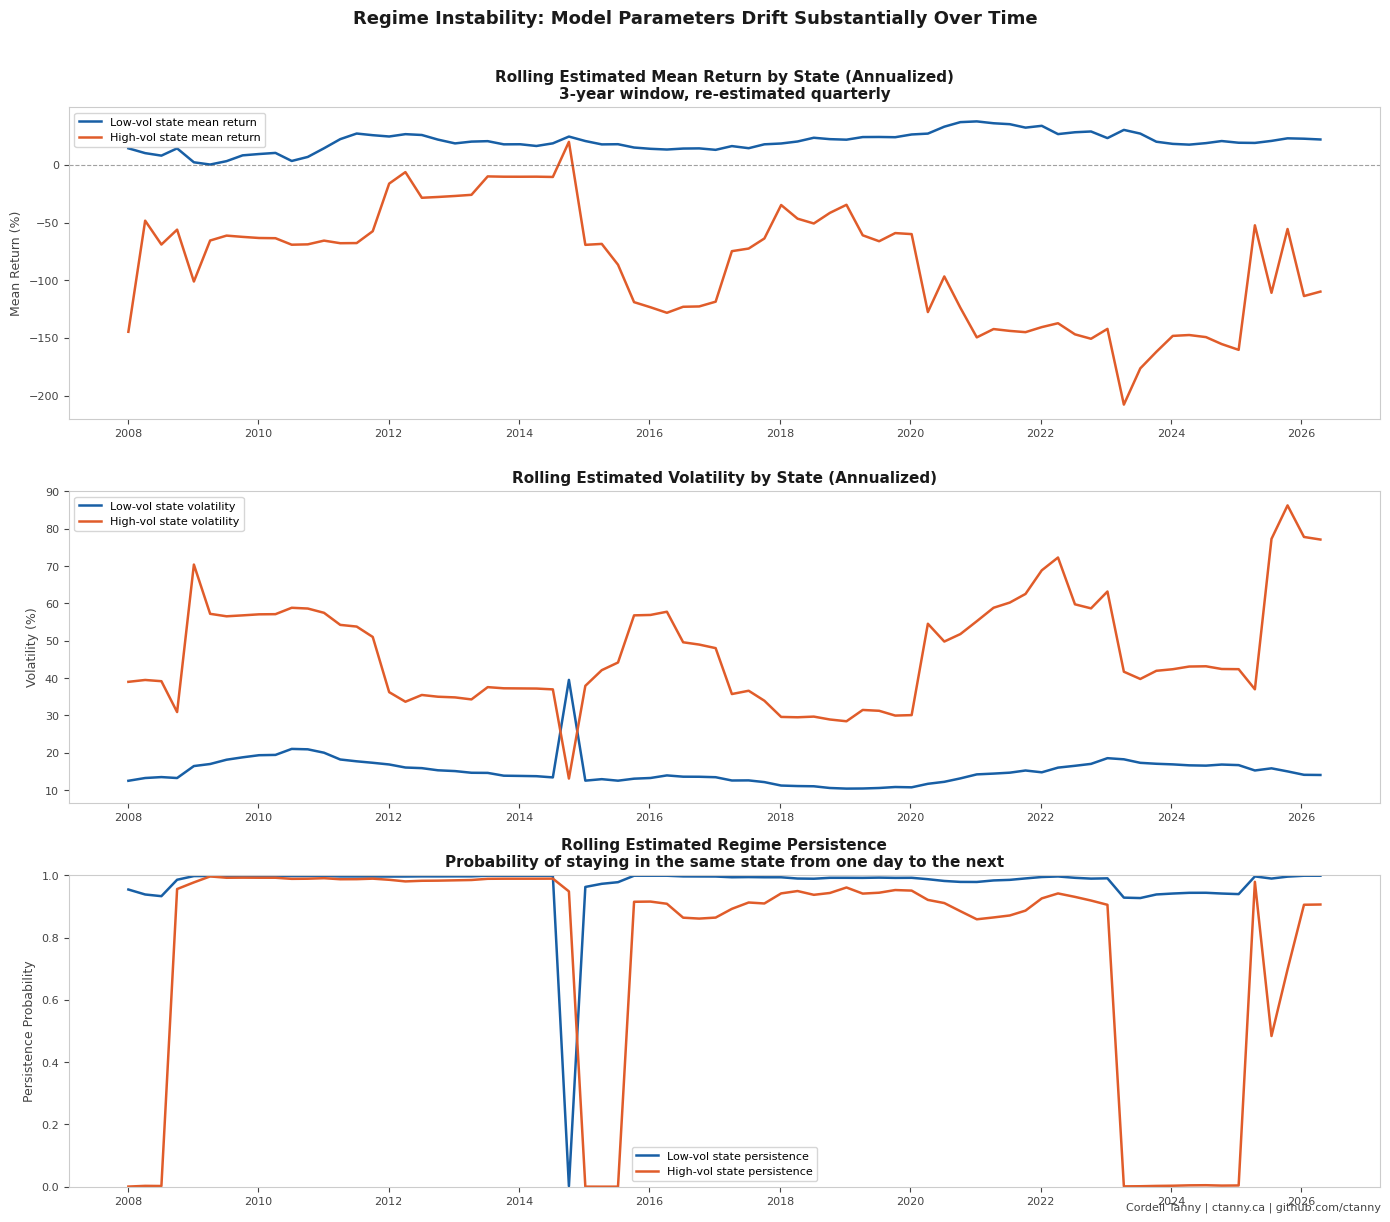

Parameter drift summary:
  Low-vol state mean return range : 0.3% to 37.7%
  High-vol state volatility range : 13.1% to 86.3%
  Low-vol persistence range       : 0.002 to 0.998


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.patch.set_facecolor('white')

# Annualized mean return in each state over time
axes[0].set_facecolor('white')
axes[0].plot(df_rolling.index, df_rolling['mean_bull'] * 100,
             color='#185FA5', linewidth=1.8, label='Low-vol state mean return')
axes[0].plot(df_rolling.index, df_rolling['mean_bear'] * 100,
             color='#E05C2A', linewidth=1.8, label='High-vol state mean return')
axes[0].axhline(0, color='#444444', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_title('Rolling Estimated Mean Return by State (Annualized)\n'
                  f'{WINDOW_YEARS}-year window, re-estimated quarterly',
                  fontsize=11, fontweight='bold', color='#1a1a1a')
axes[0].set_ylabel('Mean Return (%)', color='#444444', fontsize=9)
axes[0].legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
axes[0].tick_params(colors='#444444', labelsize=8)
for sp in axes[0].spines.values(): sp.set_edgecolor('#cccccc')

# Annualized volatility in each state over time
axes[1].set_facecolor('white')
axes[1].plot(df_rolling.index, df_rolling['vol_bull'] * 100,
             color='#185FA5', linewidth=1.8, label='Low-vol state volatility')
axes[1].plot(df_rolling.index, df_rolling['vol_bear'] * 100,
             color='#E05C2A', linewidth=1.8, label='High-vol state volatility')
axes[1].set_title('Rolling Estimated Volatility by State (Annualized)',
                  fontsize=11, fontweight='bold', color='#1a1a1a')
axes[1].set_ylabel('Volatility (%)', color='#444444', fontsize=9)
axes[1].legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
axes[1].tick_params(colors='#444444', labelsize=8)
for sp in axes[1].spines.values(): sp.set_edgecolor('#cccccc')

# Regime persistence over time
axes[2].set_facecolor('white')
axes[2].plot(df_rolling.index, df_rolling['persist_bull'],
             color='#185FA5', linewidth=1.8, label='Low-vol state persistence')
axes[2].plot(df_rolling.index, df_rolling['persist_bear'],
             color='#E05C2A', linewidth=1.8, label='High-vol state persistence')
axes[2].set_title('Rolling Estimated Regime Persistence\n'
                  'Probability of staying in the same state from one day to the next',
                  fontsize=11, fontweight='bold', color='#1a1a1a')
axes[2].set_ylabel('Persistence Probability', color='#444444', fontsize=9)
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
axes[2].tick_params(colors='#444444', labelsize=8)
for sp in axes[2].spines.values(): sp.set_edgecolor('#cccccc')

plt.suptitle('Regime Instability: Model Parameters Drift Substantially Over Time',
             fontsize=13, fontweight='bold', color='#1a1a1a', y=1.01)
plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('hmm_parameter_drift.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Parameter drift summary:")
print(f"  Low-vol state mean return range : "
      f"{df_rolling['mean_bull'].min()*100:.1f}% to {df_rolling['mean_bull'].max()*100:.1f}%")
print(f"  High-vol state volatility range : "
      f"{df_rolling['vol_bear'].min()*100:.1f}% to {df_rolling['vol_bear'].max()*100:.1f}%")
print(f"  Low-vol persistence range       : "
      f"{df_rolling['persist_bull'].min():.3f} to {df_rolling['persist_bull'].max():.3f}")

What to look for: the estimated parameters are not stable, and the degree of instability is more severe than most practitioners expect.

The low-vol state mean return shown in the top panel is the one relatively well-behaved parameter, sitting between roughly 10% and 30% annualized for most of the sample. Everything else is volatile.

The high-vol state mean return ranges from around minus 160% annualized in the early 2008 windows to briefly positive around 2014 to 2015, then back down toward minus 100% in recent windows. Around 2014 to 2015 the two lines nearly cross, meaning the model temporarily lost its ability to distinguish the two states by mean return. The labels 'low vol' and 'high vol' would have been nearly meaningless during that window.

The volatility panel is more stable for the low-vol state but shows dramatic swings for the high-vol state: peaking near 70% during the 2008 windows, declining through the calm 2012 to 2019 period, and spiking again toward 85% in the most recent windows as tariff shock volatility enters the rolling window.

The persistence panel is the most damaging of the three. The low-vol state blue line sits near 0.98 consistently throughout. The high-vol state orange line tells a completely different story. From 2007 to approximately 2014 it sits near zero, meaning the model believed you flip out of the high-volatility state almost every day. Then around 2015 it jumps sharply to near 0.95 and stays there until approximately 2023, then collapses again toward 0.4 to 0.5 in recent windows.

Think about what this means for a strategy built on this model. From 2007 to 2014, the model would tell you to re-enter the market almost immediately after a volatility spike because regime persistence is near zero. From 2015 to 2023 it would tell you to stay defensive for extended periods because persistence is near 0.95. Same model, same architecture, completely opposite behavioral implications depending on when you calibrated it.

The sharp transition around 2014 to 2015 in the persistence panel also illustrates a known problem called label switching. The model appears to have swapped the identities of state 0 and state 1 between windows during that period. When this happens, parameter series that look like they are tracking the same state over time are actually jumping between different states. Rolling window analysis of HMM parameters is treacherous for exactly this reason, and this chart shows it happening in real data.


## 9. Where HMMs Can Actually Add Value

The four failure modes above are real and they show up consistently in practice. After years of working with these models across different asset classes and market regimes, I have not found a situation where HMMs reliably improve live trading performance. That is an honest answer and I suspect more practitioners share it than are willing to say so.

That said, HMMs are not useless. The use cases where they add legitimate value tend to be analytical and research-oriented rather than directly tradeable.

| Use Case | Why It Can Work | Key Caveat |
|---|---|---|
| Risk regime classification for reporting | Provides a structured framework for describing market states to stakeholders | Regimes are still arbitrary and require human validation |
| Feature engineering for machine learning | Regime probabilities as input features rather than direct trading signals | Must use online filtering only, never in-sample Viterbi, to avoid look-ahead bias |
| Understanding historical regime structure | Academic insight into how return distributions shift across market environments | Not a live signal |
| Long-horizon macro indicator analysis | HMMs work better on monthly or quarterly economic data than on daily returns | Regime identification still lags real-time |
| Portfolio construction research | Understanding how correlations and volatilities differ across regimes | Useful for scenario analysis, not for timing |

The most technically interesting legitimate use case is feature engineering for machine learning. The idea is to pass the filtered state probabilities as input features into a downstream model rather than trading on them directly. This sidesteps the threshold problem entirely because the downstream model learns how to weight the regime signal alongside other features. The critical requirement is that you must use online filtering at every point in time, computing the probability using only data available up to that moment. Using in-sample Viterbi decoded states as features for a forward-looking model is a form of look-ahead bias that will produce impressive in-sample results and fail live. Given the 47% non-convergence rate we observed in rolling estimation, the stability of these features across re-calibration windows is also a concern that deserves testing before deployment.

### Alternatives to the Standard Gaussian HMM

Since we have demonstrated that Gaussian emissions and Viterbi decoding both have serious limitations, it is worth briefly addressing the alternatives.

On the emission side, a Student-t HMM is a more statistically honest choice given what we know about fat-tailed return distributions from the first two notebooks in this series. It captures excess kurtosis within each state rather than forcing a Gaussian shape. The trade-off is that it adds parameters, and more parameters make the convergence problem worse. The 47% non-convergence rate in the Gaussian case would likely increase with a Student-t specification.

A mixture of Gaussians emission gives the model even more flexibility to fit complex return distributions within each state. The same trade-off applies: more flexibility, worse convergence, and all four structural failure modes remain completely unchanged. You are decorating the model without addressing its fundamental weaknesses.

On the decoding side, posterior decoding uses the full smoothed probability at each time step rather than the single most likely path. It is more honest about uncertainty and avoids the label-switching problem to some degree. But it produces fractional state assignments rather than binary ones, which makes building a strategy on the output more complex without solving the real-time uncertainty problem.

Particle filtering handles non-linear and non-Gaussian models through sequential Monte Carlo methods. It is computationally expensive and genuinely overkill for most financial applications. It would not address the labeling arbitrariness or parameter instability problems.

The honest conclusion is that the alternatives improve statistical honesty but do not fix the four structural failure modes documented in this notebook. The hindsight problem, the labeling problem, the real-time uncertainty problem, and the parameter instability problem are not a consequence of using Gaussian emissions or Viterbi decoding. They are a consequence of what HMMs are and how financial return data behaves.


## 10. Key Takeaways

1. An HMM is not a Markov chain.

In a Markov chain, states are directly observable. In an HMM, states are hidden and can only be inferred probabilistically from observed outputs. Every practical limitation in this notebook flows from that distinction.

2. In-sample regime decoding uses the full history and will always look clean.

The Viterbi algorithm assigns regimes with perfect hindsight. The real-time filtered estimate disagreed with Viterbi on 8.1% of trading days in our SPY analysis, but that disagreement was concentrated entirely at regime transitions, which are the only days a regime-following strategy would act. When it matters, the disagreement rate is close to 100%.

3. The number of states is a researcher choice, not a data-driven answer.

Fitting 2, 3, and 4 states on the same SPY data produced three completely different regime maps. The 3-state model switched states almost daily in what appeared to be a stable period, a sign of overfitting rather than insight. There is no objective criterion for choosing how many states to use.

4. Real-time filtered probabilities are often uncertain, and the threshold choice matters enormously.

The model spent significant time with filtered probabilities in the 0.4 to 0.7 range during transition periods. Using a 50% threshold produced roughly 21% bear signal days. Using a 90% threshold reduced that to about 8%. More critically, the real-time estimate generated 284 regime transitions versus 56 for Viterbi, five times more signal changes, which translates directly into transaction costs and whipsaws.

5. Model parameters drift substantially as market structure changes.

Across 74 rolling 3-year windows, the high-vol state mean return ranged from minus 160% to briefly positive, the high-vol volatility ranged from 13% to 86%, and the high-vol persistence ranged from near zero to near 0.98. A strategy calibrated when persistence was near zero would trade completely differently from one calibrated when persistence was near 0.98. The model also failed to converge on 47% of rolling windows, meaning nearly half the re-estimations in a live context return parameters from an unconverged solution. Label switching between windows makes rolling parameter tracking unreliable.

6. There are legitimate uses, but they are narrower than most tutorials suggest.

Risk reporting, feature engineering for machine learning models, and long-horizon macro analysis can all benefit from HMMs when used carefully with online filtering and realistic expectations. The alternatives to Gaussian HMM, including Student-t emissions, mixture of Gaussians, and posterior decoding, improve statistical honesty without addressing the four structural failure modes. The problems documented in this notebook are not a consequence of implementation choices. They are a consequence of what HMMs are.

---

What comes next:

If regime detection is something you want to pursue, the more practical path is to look at observable signal-based approaches: threshold indicators built on the VIX, credit spreads, or market breadth, and rolling volatility regimes that do not require a hidden state assumption. These have their own limitations but they are transparent, real-time, and do not require a convergence step.

---

*Cordell Tanny, CFA, FRM, FDP*  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny/quant-finance-snippets](https://github.com/ctanny/quant-finance-snippets)  
*Questions or ideas? Connect on LinkedIn.*


## Disclaimers
This notebook is for educational and informational purposes only. Nothing contained here constitutes investment advice, a solicitation, or a recommendation to buy or sell any security or financial instrument. The analysis presented uses historical data and is intended to illustrate statistical and methodological concepts, not to predict future market behavior or returns. Past performance is not indicative of future results. All investing involves risk, including the possible loss of principal. The views expressed are those of the author alone and do not represent the views of any institution or employer. Readers should consult a qualified financial professional before making any investment decisions.